# 📊 Market Risk Engine
## Multi-Asset VaR & Backtesting Framework
---
**Nelson Arafat ZOUATOM** | Étudiant Ingénieur Finance — ESIGELEC  
*Python · NumPy · Pandas · SciPy · Monte Carlo · Yahoo Finance API*

##  Installation 

In [2]:
!pip install yfinance pandas numpy matplotlib scipy seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##  Imports et configuration 

In [3]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Librairies chargées avec succès")

✅ Librairies chargées avec succès


## Collecte des données 

In [4]:
# Portefeuille multi-actifs : Tech + Finance + Energie + Santé + ETF
tickers = {
    'AAPL': 'Apple (Tech)',
    'JPM':  'JPMorgan (Finance)',
    'XOM':  'ExxonMobil (Energie)',
    'JNJ':  'Johnson & Johnson (Santé)',
    'SPY':  'S&P 500 ETF (Benchmark)'
}

# 5 ans d'historique
print("📡 Téléchargement des données...")
raw = yf.download(list(tickers.keys()), start='2019-01-01', end='2024-01-01')['Close']
prices = raw.dropna()

print(f"\n✅ Données récupérées : {len(prices)} jours de trading")
print(f"   Période : {prices.index[0].date()} → {prices.index[-1].date()}")
prices.tail(3)

📡 Téléchargement des données...


[*********************100%***********************]  5 of 5 completed


✅ Données récupérées : 1258 jours de trading
   Période : 2019-01-02 → 2023-12-29


Ticker,AAPL,JNJ,JPM,SPY,XOM
Date,,,,,
2023-12-27,190.988129,146.273071,160.470627,463.747833,93.563438
2023-12-28,191.413330,146.488251,161.323166,463.923035,92.210533
2023-12-29,190.375046,146.637939,161.133728,462.579956,92.017235


## 📊 Rendements logarithmiques

In [5]:
# Rendements log journaliers
returns = np.log(prices / prices.shift(1)).dropna()

# Poids du portefeuille (équipondéré)
weights = np.array([0.25, 0.25, 0.25, 0.25, 0.0])  # SPY = benchmark, pas dans le portef.
weights_labels = ['AAPL', 'JPM', 'XOM', 'JNJ']

# Rendements du portefeuille (hors SPY)
portfolio_returns = returns[weights_labels].dot(weights[:4])

print("📈 Statistiques du portefeuille :")
print(f"   Rendement moyen journalier : {portfolio_returns.mean()*100:.4f}%")
print(f"   Volatilité journalière     : {portfolio_returns.std()*100:.4f}%")
print(f"   Rendement annualisé        : {portfolio_returns.mean()*252*100:.2f}%")
print(f"   Volatilité annualisée      : {portfolio_returns.std()*np.sqrt(252)*100:.2f}%")

📈 Statistiques du portefeuille :
   Rendement moyen journalier : 0.0651%
   Volatilité journalière     : 1.4116%
   Rendement annualisé        : 16.40%
   Volatilité annualisée      : 22.41%


##  Calcul de la VaR  

In [6]:
# ── Paramètres ──────────────────────────────────────────────

portfolio_value = 1_000_000  # 1 million €
confidence_95   = 0.95
confidence_99   = 0.99

# ── Méthode 1 : VaR Historique ───────────────────────────────
var_hist_95 = np.percentile(portfolio_returns, (1 - confidence_95) * 100)
var_hist_99 = np.percentile(portfolio_returns, (1 - confidence_99) * 100)

# ── Méthode 2 : VaR Paramétrique (loi normale) ───────────────
mu    = portfolio_returns.mean()
sigma = portfolio_returns.std()
var_param_95 = stats.norm.ppf(1 - confidence_95, mu, sigma)
var_param_99 = stats.norm.ppf(1 - confidence_99, mu, sigma)

# ── Méthode 3 : VaR Monte Carlo (10 000 simulations) ─────────
np.random.seed(42)
n_simulations = 10_000
simulated_returns = np.random.normal(mu, sigma, n_simulations)
var_mc_95 = np.percentile(simulated_returns, (1 - confidence_95) * 100)
var_mc_99 = np.percentile(simulated_returns, (1 - confidence_99) * 100)

# ── Résultats en euros ────────────────────────────────────────
print("=" * 55)
print(f"{'MÉTHODE':<20} {'VaR 95%':>15} {'VaR 99%':>15}")
print("=" * 55)
print(f"{'Historique':<20} {var_hist_95*portfolio_value:>14,.0f}€ {var_hist_99*portfolio_value:>14,.0f}€")
print(f"{'Paramétrique':<20} {var_param_95*portfolio_value:>14,.0f}€ {var_param_99*portfolio_value:>14,.0f}€")
print(f"{'Monte Carlo':<20} {var_mc_95*portfolio_value:>14,.0f}€ {var_mc_99*portfolio_value:>14,.0f}€")
print("=" * 55)
print(f"\n💼 Portefeuille : {portfolio_value:,.0f}€")
print(f"📅 Période d'analyse : {returns.index[0].date()} → {returns.index[-1].date()}")

MÉTHODE                      VaR 95%         VaR 99%
Historique                  -19,554€        -37,170€
Paramétrique                -22,567€        -32,187€
Monte Carlo                 -22,709€        -32,105€

💼 Portefeuille : 1,000,000€
📅 Période d'analyse : 2019-01-03 → 2023-12-29


## 📉Visualisation VaR

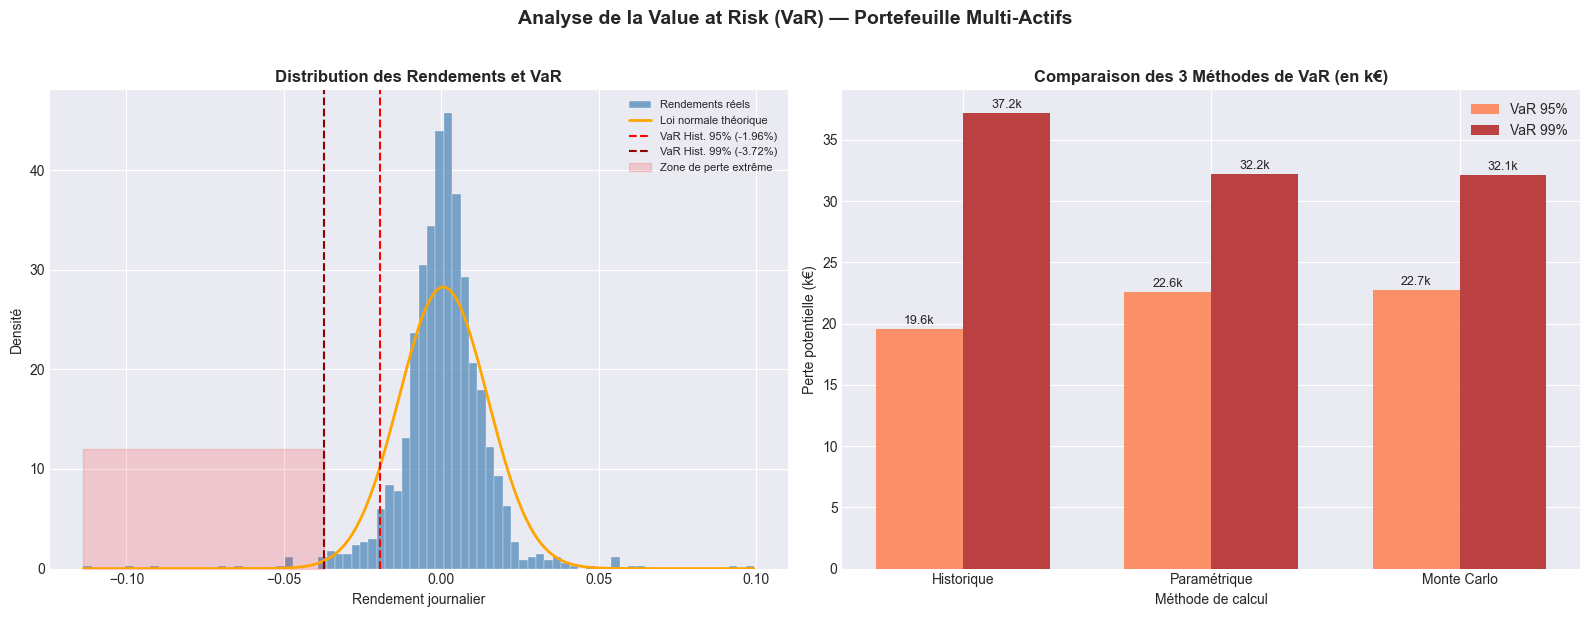

✅ Graphique sauvegardé : var_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analyse de la Value at Risk (VaR) — Portefeuille Multi-Actifs",
             fontsize=14, fontweight='bold', y=1.02)

# ── Graphique 1 : Distribution des rendements ─────────────────

ax1 = axes[0]
ax1.hist(portfolio_returns, bins=80, color='steelblue', alpha=0.7,
         edgecolor='white', linewidth=0.3, density=True, label='Rendements réels')

# Courbe normale théorique

x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 300)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'orange', linewidth=2, label='Loi normale théorique')

# Lignes VaR

ax1.axvline(var_hist_95, color='red',    linestyle='--', linewidth=1.5, label=f'VaR Hist. 95% ({var_hist_95*100:.2f}%)')
ax1.axvline(var_hist_99, color='darkred',linestyle='--', linewidth=1.5, label=f'VaR Hist. 99% ({var_hist_99*100:.2f}%)')
ax1.fill_betweenx([0, 12], portfolio_returns.min(), var_hist_99,
                  alpha=0.15, color='red', label='Zone de perte extrême')

ax1.set_title('Distribution des Rendements et VaR', fontweight='bold')
ax1.set_xlabel('Rendement journalier')
ax1.set_ylabel('Densité')
ax1.legend(fontsize=8)

# ── Graphique 2 : Comparaison des 3 méthodes ─────────────────

ax2 = axes[1]
methods = ['Historique', 'Paramétrique', 'Monte Carlo']
var_95_vals = [abs(var_hist_95), abs(var_param_95), abs(var_mc_95)]
var_99_vals = [abs(var_hist_99), abs(var_param_99), abs(var_mc_99)]

x_pos = np.arange(len(methods))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, [v * portfolio_value / 1000 for v in var_95_vals],
                width, label='VaR 95%', color='coral', alpha=0.85)
bars2 = ax2.bar(x_pos + width/2, [v * portfolio_value / 1000 for v in var_99_vals],
                width, label='VaR 99%', color='firebrick', alpha=0.85)

ax2.set_title('Comparaison des 3 Méthodes de VaR (en k€)', fontweight='bold')
ax2.set_xlabel('Méthode de calcul')
ax2.set_ylabel('Perte potentielle (k€)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(methods)
ax2.legend()

# Valeurs sur les barres
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}k', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}k', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('var_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : var_analysis.png")

## 📊 Corrélations entre actifs 

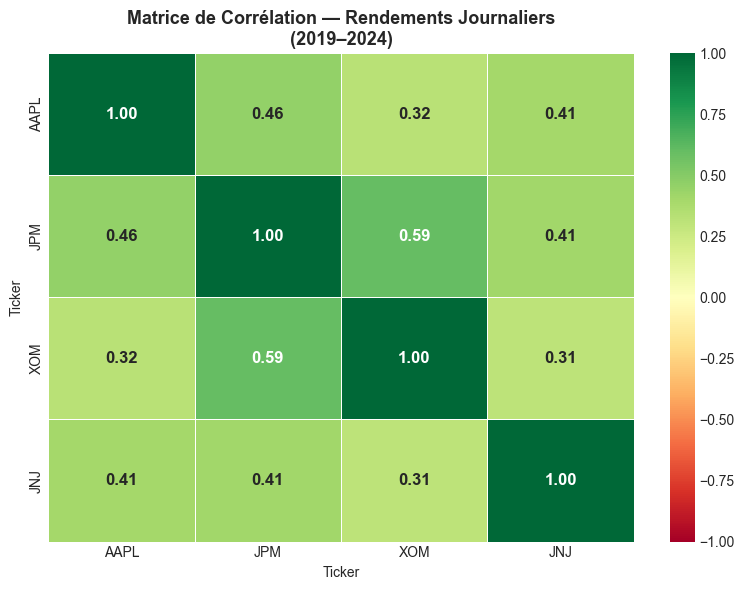

✅ Graphique sauvegardé : correlation_matrix.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = returns[weights_labels].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('Matrice de Corrélation — Rendements Journaliers\n(2019–2024)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : correlation_matrix.png")

## Stratégie Trend Following (MA50 vs MA200)

In [9]:
# On travaille sur AAPL comme actif principal pour le backtesting
asset = 'AAPL'
price_series = prices[asset].copy()

# Calcul des moyennes mobiles
ma50  = price_series.rolling(window=50).mean()
ma200 = price_series.rolling(window=200).mean()

# Signal : 1 = on est investi, 0 = on sort du marché
signal = (ma50 > ma200).astype(int)

# Rendements journaliers de la stratégie
asset_returns   = np.log(price_series / price_series.shift(1))
strategy_returns = signal.shift(1) * asset_returns  # shift(1) pour éviter le look-ahead bias
benchmark_returns = returns['SPY']

# Suppression des NaN
strategy_returns  = strategy_returns.dropna()
benchmark_returns = benchmark_returns.loc[strategy_returns.index]

print("✅ Stratégie Trend Following construite")
print(f"   Actif principal : {asset}")
print(f"   Période : {strategy_returns.index[0].date()} → {strategy_returns.index[-1].date()}")
print(f"   Nombre de jours tradés : {signal.sum()} / {len(signal)}")

✅ Stratégie Trend Following construite
   Actif principal : AAPL
   Période : 2019-01-03 → 2023-12-29
   Nombre de jours tradés : 868 / 1258


##  Calcul des métriques de performance

In [11]:
# ── Sharpe Ratio ─────────────────────────────────────────────
risk_free_rate = 0.02 / 252  # Taux sans risque journalier (2% annuel)

sharpe_strategy  = (strategy_returns.mean() - risk_free_rate) / strategy_returns.std() * np.sqrt(252)
sharpe_benchmark = (benchmark_returns.mean() - risk_free_rate) / benchmark_returns.std() * np.sqrt(252)

# ── Maximum Drawdown ─────────────────────────────────────────
def max_drawdown(returns_series):
    cumulative = (1 + returns_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

mdd_strategy  = max_drawdown(strategy_returns)
mdd_benchmark = max_drawdown(benchmark_returns)

# ── Rendement annualisé ──────────────────────────────────────
annual_return_strategy  = strategy_returns.mean() * 252
annual_return_benchmark = benchmark_returns.mean() * 252

# ── Volatilité annualisée ────────────────────────────────────
vol_strategy  = strategy_returns.std() * np.sqrt(252)
vol_benchmark = benchmark_returns.std() * np.sqrt(252)

# ── Affichage ────────────────────────────────────────────────
print("=" * 52)
print(f"{'MÉTRIQUE':<28} {'STRATÉGIE':>10} {'S&P 500':>10}")
print("=" * 52)
print(f"{'Sharpe Ratio':<28} {sharpe_strategy:>10.2f} {sharpe_benchmark:>10.2f}")
print(f"{'Rendement annualisé':<28} {annual_return_strategy*100:>9.2f}% {annual_return_benchmark*100:>9.2f}%")
print(f"{'Volatilité annualisée':<28} {vol_strategy*100:>9.2f}% {vol_benchmark*100:>9.2f}%")
print(f"{'Maximum Drawdown':<28} {mdd_strategy*100:>9.2f}% {mdd_benchmark*100:>9.2f}%")
print("=" * 52)

print(f"\n💡 Sharpe Ratio Stratégie : {sharpe_strategy:.2f}")
if sharpe_strategy > sharpe_benchmark:
    print(f"   ✅ Supérieur au benchmark ({sharpe_benchmark:.2f})")
else:
    print(f"   ⚠️  Inférieur au benchmark ({sharpe_benchmark:.2f})")

MÉTRIQUE                      STRATÉGIE    S&P 500
Sharpe Ratio                       0.70       0.59
Rendement annualisé              21.22%     14.50%
Volatilité annualisée            27.42%     21.08%
Maximum Drawdown                -34.34%    -35.75%

💡 Sharpe Ratio Stratégie : 0.70
   ✅ Supérieur au benchmark (0.59)


## 📉 Courbe de performance cumulée

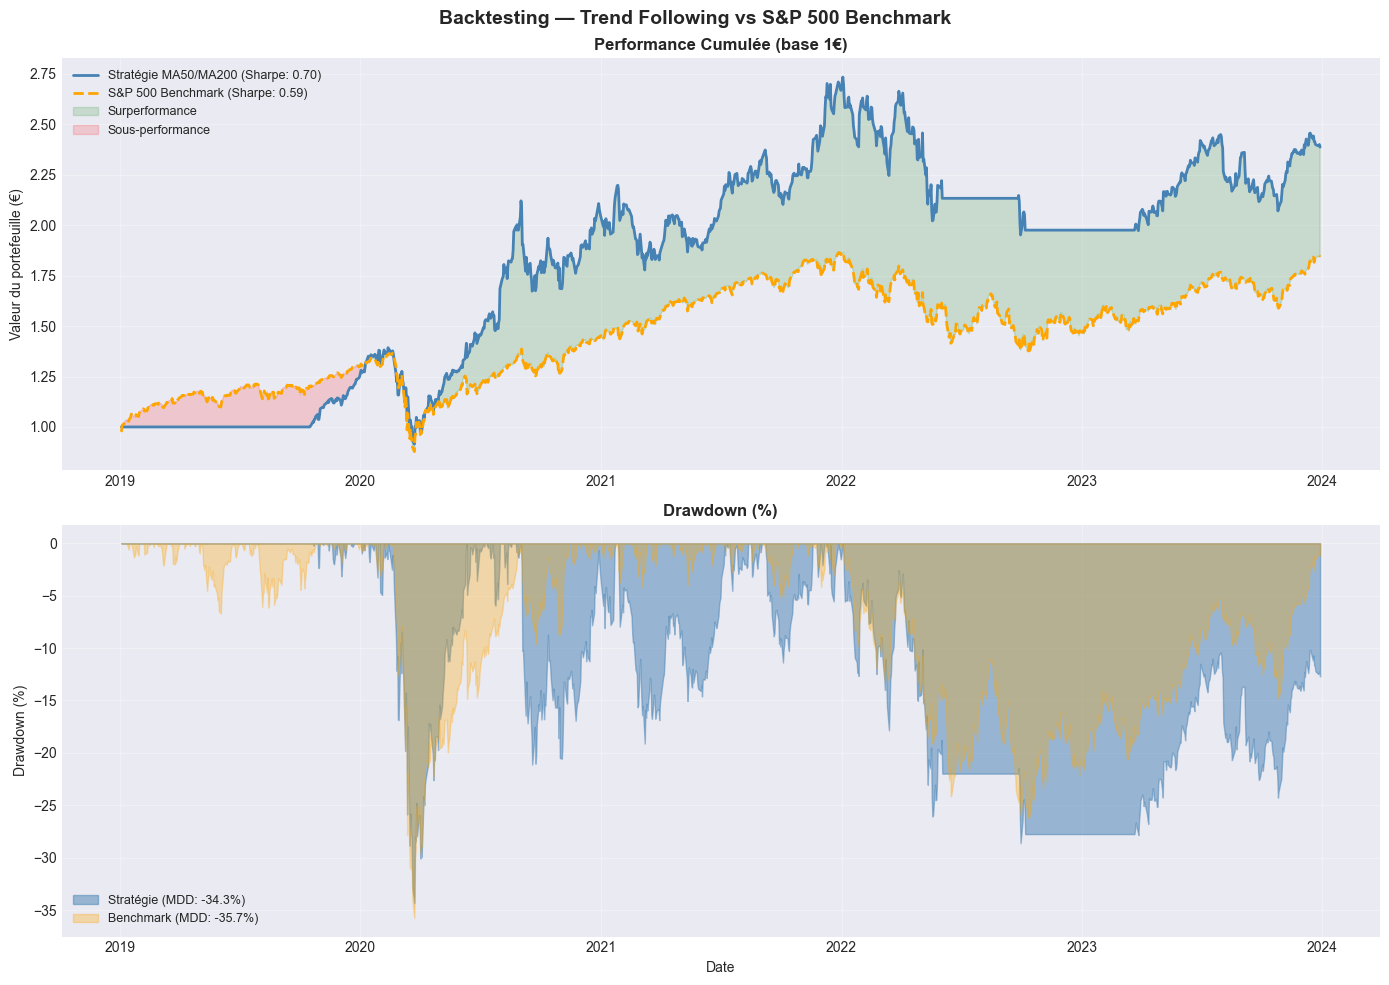

✅ Graphique sauvegardé : backtesting_performance.png


In [12]:
# Performance cumulée
cumul_strategy  = (1 + strategy_returns).cumprod()
cumul_benchmark = (1 + benchmark_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Backtesting — Trend Following vs S&P 500 Benchmark',
             fontsize=14, fontweight='bold')

# ── Graphique 1 : Performance cumulée ────────────────────────
ax1 = axes[0]
ax1.plot(cumul_strategy.index,  cumul_strategy,  color='steelblue', linewidth=2,
         label=f'Stratégie MA50/MA200 (Sharpe: {sharpe_strategy:.2f})')
ax1.plot(cumul_benchmark.index, cumul_benchmark, color='orange',    linewidth=2,
         linestyle='--', label=f'S&P 500 Benchmark (Sharpe: {sharpe_benchmark:.2f})')
ax1.fill_between(cumul_strategy.index, cumul_strategy, cumul_benchmark,
                 where=cumul_strategy >= cumul_benchmark,
                 alpha=0.15, color='green', label='Surperformance')
ax1.fill_between(cumul_strategy.index, cumul_strategy, cumul_benchmark,
                 where=cumul_strategy < cumul_benchmark,
                 alpha=0.15, color='red', label='Sous-performance')
ax1.set_title('Performance Cumulée (base 1€)', fontweight='bold')
ax1.set_ylabel('Valeur du portefeuille (€)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Graphique 2 : Drawdown ───────────────────────────────────
ax2 = axes[1]
drawdown_strat = (cumul_strategy - cumul_strategy.cummax()) / cumul_strategy.cummax()
drawdown_bench = (cumul_benchmark - cumul_benchmark.cummax()) / cumul_benchmark.cummax()

ax2.fill_between(drawdown_strat.index, drawdown_strat * 100, 0,
                 color='steelblue', alpha=0.5, label=f'Stratégie (MDD: {mdd_strategy*100:.1f}%)')
ax2.fill_between(drawdown_bench.index, drawdown_bench * 100, 0,
                 color='orange', alpha=0.3, label=f'Benchmark (MDD: {mdd_benchmark*100:.1f}%)')
ax2.set_title('Drawdown (%)', fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('backtesting_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : backtesting_performance.png")

## 🎯 Cellule 11 — Dashboard Final (vue d'ensemble)

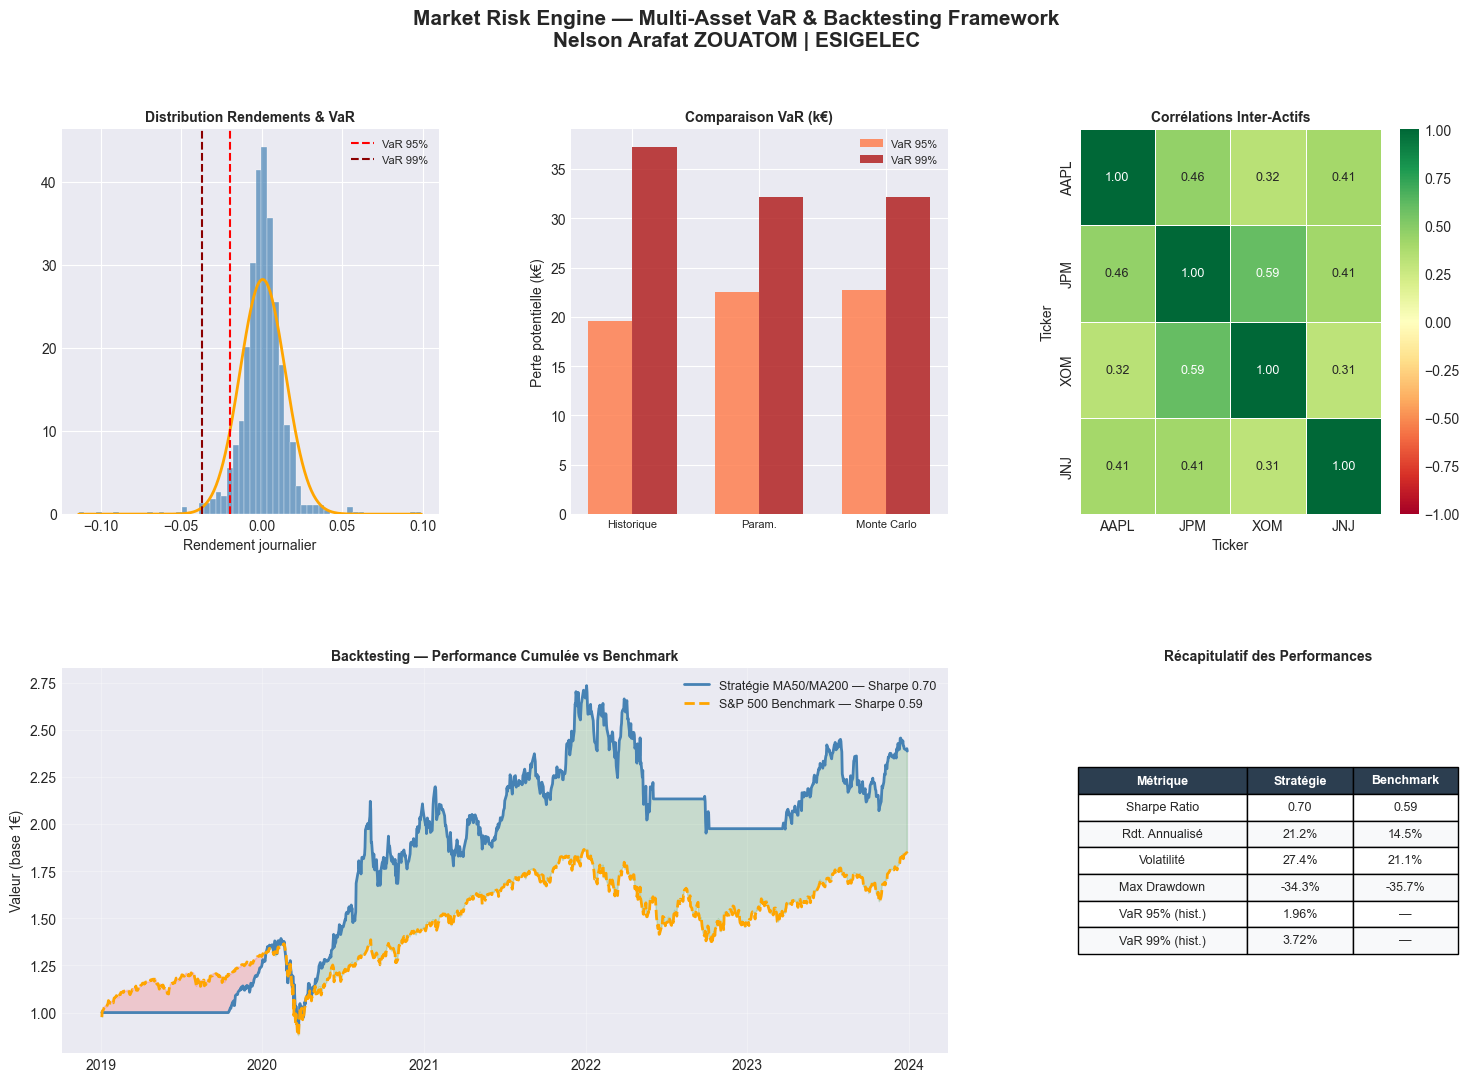

✅ Dashboard final sauvegardé : dashboard_final.png

🎯 SHARPE RATIO RÉEL : 0.70
📉 MAX DRAWDOWN RÉEL : -34.34%
📈 RENDEMENT ANNUALISÉ RÉEL : 21.22%


In [13]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Market Risk Engine — Multi-Asset VaR & Backtesting Framework\nNelson Arafat ZOUATOM | ESIGELEC',
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1 : Distribution des rendements + VaR ──────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(portfolio_returns, bins=60, color='steelblue', alpha=0.7,
         edgecolor='white', linewidth=0.3, density=True)
x_range = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 300)
ax1.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'orange', linewidth=2)
ax1.axvline(var_hist_95, color='red',     linestyle='--', linewidth=1.5, label=f'VaR 95%')
ax1.axvline(var_hist_99, color='darkred', linestyle='--', linewidth=1.5, label=f'VaR 99%')
ax1.set_title('Distribution Rendements & VaR', fontweight='bold', fontsize=10)
ax1.set_xlabel('Rendement journalier')
ax1.legend(fontsize=8)

# ── Panel 2 : Comparaison méthodes VaR ───────────────────────
ax2 = fig.add_subplot(gs[0, 1])
methods = ['Historique', 'Param.', 'Monte Carlo']
var_95_vals = [abs(var_hist_95), abs(var_param_95), abs(var_mc_95)]
var_99_vals = [abs(var_hist_99), abs(var_param_99), abs(var_mc_99)]
x_pos = np.arange(len(methods))
width = 0.35
ax2.bar(x_pos - width/2, [v * portfolio_value / 1000 for v in var_95_vals],
        width, label='VaR 95%', color='coral', alpha=0.85)
ax2.bar(x_pos + width/2, [v * portfolio_value / 1000 for v in var_99_vals],
        width, label='VaR 99%', color='firebrick', alpha=0.85)
ax2.set_title('Comparaison VaR (k€)', fontweight='bold', fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(methods, fontsize=8)
ax2.set_ylabel('Perte potentielle (k€)')
ax2.legend(fontsize=8)

# ── Panel 3 : Matrice de corrélation ─────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
corr = returns[weights_labels].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax3,
            linewidths=0.5, annot_kws={'size': 9})
ax3.set_title('Corrélations Inter-Actifs', fontweight='bold', fontsize=10)

# ── Panel 4 : Performance cumulée (backtesting) ───────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.plot(cumul_strategy.index,  cumul_strategy,  color='steelblue', linewidth=2,
         label=f'Stratégie MA50/MA200 — Sharpe {sharpe_strategy:.2f}')
ax4.plot(cumul_benchmark.index, cumul_benchmark, color='orange',    linewidth=2,
         linestyle='--', label=f'S&P 500 Benchmark — Sharpe {sharpe_benchmark:.2f}')
ax4.fill_between(cumul_strategy.index, cumul_strategy, cumul_benchmark,
                 where=cumul_strategy >= cumul_benchmark, alpha=0.15, color='green')
ax4.fill_between(cumul_strategy.index, cumul_strategy, cumul_benchmark,
                 where=cumul_strategy < cumul_benchmark, alpha=0.15, color='red')
ax4.set_title('Backtesting — Performance Cumulée vs Benchmark', fontweight='bold', fontsize=10)
ax4.set_ylabel('Valeur (base 1€)')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ── Panel 5 : Tableau récapitulatif des métriques ────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
table_data = [
    ['Métrique', 'Stratégie', 'Benchmark'],
    ['Sharpe Ratio', f'{sharpe_strategy:.2f}', f'{sharpe_benchmark:.2f}'],
    ['Rdt. Annualisé', f'{annual_return_strategy*100:.1f}%', f'{annual_return_benchmark*100:.1f}%'],
    ['Volatilité', f'{vol_strategy*100:.1f}%', f'{vol_benchmark*100:.1f}%'],
    ['Max Drawdown', f'{mdd_strategy*100:.1f}%', f'{mdd_benchmark*100:.1f}%'],
    ['VaR 95% (hist.)', f'{abs(var_hist_95)*100:.2f}%', '—'],
    ['VaR 99% (hist.)', f'{abs(var_hist_99)*100:.2f}%', '—'],
]
table = ax5.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center',
                  colWidths=[0.45, 0.28, 0.28])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Header styling
for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row styling
for i in range(1, len(table_data)):
    for j in range(3):
        table[i, j].set_facecolor('#f8f9fa' if i % 2 == 0 else 'white')

ax5.set_title('Récapitulatif des Performances', fontweight='bold', fontsize=10)

plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard final sauvegardé : dashboard_final.png")
print(f"\n🎯 SHARPE RATIO RÉEL : {sharpe_strategy:.2f}")
print(f"📉 MAX DRAWDOWN RÉEL : {mdd_strategy*100:.2f}%")
print(f"📈 RENDEMENT ANNUALISÉ RÉEL : {annual_return_strategy*100:.2f}%")